In [52]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
import numpy as np
import torch
import seaborn as sns
import itertools
from tqdm.auto import tqdm

# Simplest Implementation of Diffusion Models

**Source:** [Tutoriel de Emilo's blog](https://e-dorigatti.github.io/math/deep%20learning/2023/06/25/diffusion.html)

Diffusion refers to the gradual corruption of training examples by repeatedly adding a small amount of noise, mimicking the way heat diffuses through a material until it reaches an uniform temperature. After a few hundreds or thousands of noise diffusion steps, the information in the original sample is completely lost, such that the result is indistinguishable from the Gaussian that we will use as a starting point to generate new samples. Figure 2 from the paper (Ho, 2020) demonstrates this process graphically:

![Texte alternatif](ressources/diffusion.png "Titre de l'image")

Here, $x_0$ is the original sample, the image of a guy, and the process of adding noise is represented by the dashed arrow going from right to left, so that, after $T$ steps, only noise remains in $x_T$. The generative process is represented by the arrows going from left to right, from $x_T$ to $x_0$, and the generative model is denoted by $p_\theta$, while the noise-adding process is $q$.

In this tutorial, we will learn to generate samples from a very simple unidimensional distribution, so that we can easily visualize the generative process. Let’s start by generating some data:

# Création du Dataset

Définie 2 variable aléatoire via `means` et `stds` qui sont tiré aleatoirement via un label.

Ce qui permet d'avoir deux distributions melanger,
$$ q(x_0) = \sum_{k=1}^{K} \pi_k \cdot \mathcal{N}(\mu_k,\sigma_k) $$

Ou un label est associé aux valeur de facon a avoir $(x_i,y_i)$ avec,
- $y=0$ : gaussienne centré sur -4
- $y=1$ : gaussienne centré sur 4

In [53]:
N = 50000

# labels : 0 ou 1
labels = torch.randint(0, 2, (N,))

means = torch.tensor([
    [-8., -4., -1.],   # label 0
    [ 1.,  4.,  8.]    # label 1
])

stds = torch.tensor([
    [2., 1., 0.5],
    [0.5, 1., 2.]
])

M = means.shape[1]

components = torch.randint(0, M, (N,))

dataset = torch.normal(
    means[labels, components],
    stds [labels, components]
).unsqueeze(-1)

print(dataset.shape) # [1000,1]
print(labels.shape)  # [1000]


data_distribution = torch.distributions.MixtureSameFamily(
    torch.distributions.Categorical(
        torch.ones(6) / 6
    ),
    torch.distributions.Normal(
        torch.tensor([-8., -4., -1., 1., 4., 8.]),
        torch.tensor([ 2.,  1., 0.5, 0.5, 1., 2.])
    )
)

torch.Size([50000, 1])
torch.Size([50000])


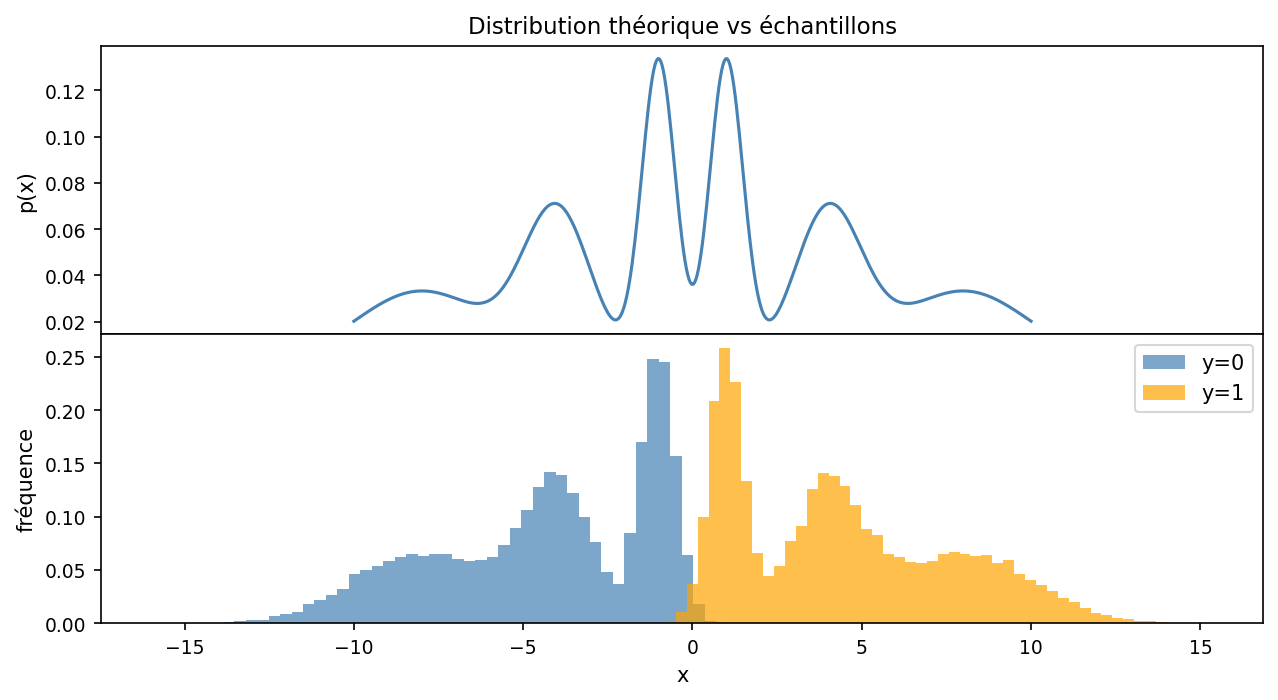

In [54]:
fig, ax = plt.subplots(2, 1, figsize=(10, 5), sharex=True)


# --- ax[0] : la vraie densité (PDF) ---
x = torch.linspace(-10, 10, 500)                # grille de 500 points entre -10 et 10
pdf = data_distribution.log_prob(x).exp()       # p(x) = exp(log p(x)), car torch donne toujour le log de la proba 
ax[0].plot(x.numpy(), pdf.numpy(), color='steelblue')
ax[0].set_title('Distribution théorique vs échantillons')
ax[0].set_ylabel("p(x)")

# --- ax[1] : histogramme des échantillons ---
ax[1].hist(
    dataset[labels == 0],
    bins=50,
    density=True,
    alpha=0.7,
    color='steelblue',
    label='y=0'
)

ax[1].hist(
    dataset[labels == 1],
    bins=50,
    density=True,
    alpha=0.7,
    color='orange',
    label='y=1'
)

ax[1].legend()
ax[1].set_xlabel("x")
ax[1].set_ylabel("fréquence")

fig.subplots_adjust(hspace=0)
plt.show()

## Diffusion Process

Equation du processus de diffusion foward:
$$q(x_{1:T} | x_0) := \prod_{t=1}^{T} q(x_t | x_{t-1})$$
Le processus de diffusion est une chaîne de Markov : pour simuler toute la trajectoire du bruit, il suffit d'appliquer T petites étapes successives et indépendantes, chacune ajoutant un peu de bruit à partir de l'état précédent. 
Ces étapes d'ajouts s'écrivent comme, 
$$ q(x_t | x_{t-1}) := \mathcal{N}(x_t|\sqrt{1-\beta_t} \, x_{t-1};\beta_t \textbf{I}) $$
Ou la moyenne et la variances sont choisi de tel sorte que la sortie de la distribution pour $x_T$ ai une moyenne nulle et une variance unitaire. Et $\beta$ est la quantité de bruit ajouté a chaque étape.

In [55]:
# Parametres
TIME_STEPS = 250
BETA = 0.02

In [56]:
def do_diffusion(data, steps=100, beta=0.02):
    """_summary_
    Perform diffusion following equation 1 in diffusion process

    Args:
        data (_type_): Data to apply diffusion on
        steps (int, optional): number of add noise iteration. Defaults to TIME_STEPS.
        beta (float, optional): how much noise is added at each step. Defaults to BETA.

    Returns:
        list: (x(t)) and x(t)
    """
    distributions, samples = [None], [data]
    xt = data
    for t in range(steps):
        q = torch.distributions.Normal(
            np.sqrt(1 - beta) * xt,
            np.sqrt(beta)
        )
        xt = q.sample()

        distributions.append(q)
        samples.append(xt)

    return distributions, samples

In [57]:
_, samples = do_diffusion(dataset, TIME_STEPS, BETA)

Text(0.5, 1.0, 'Diffusion process')

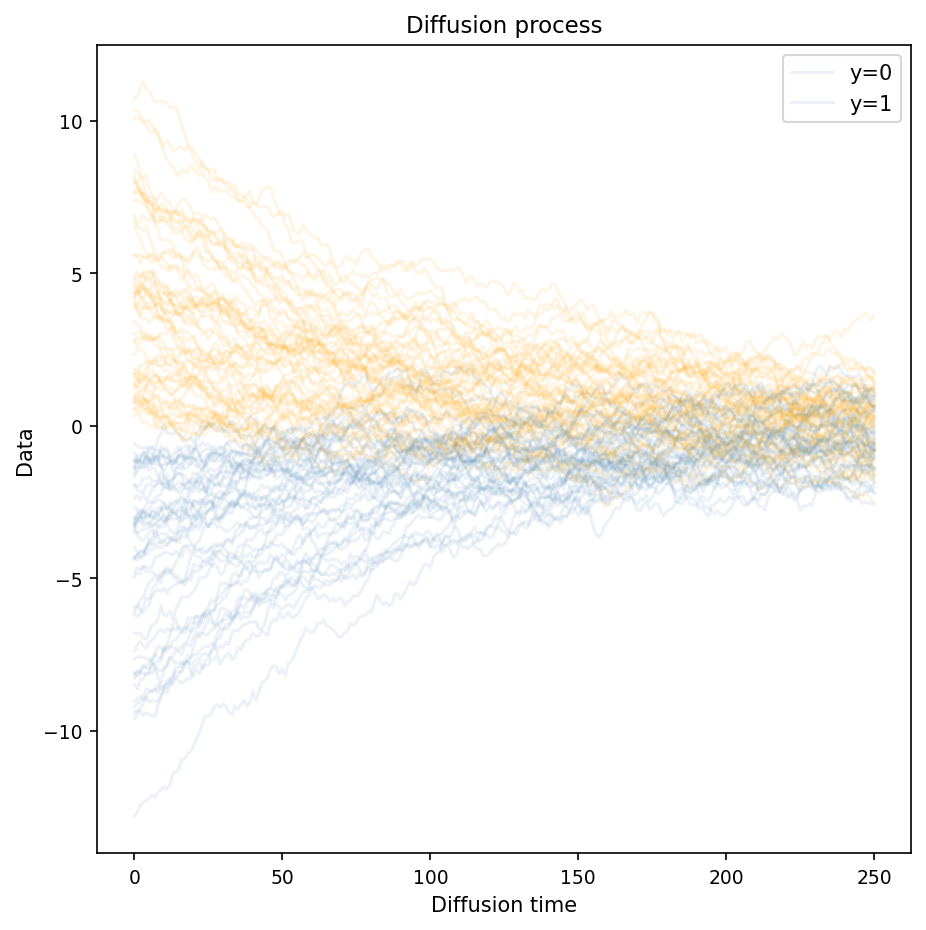

In [58]:
fig, ax = plt.subplots(1, 1, figsize=(7, 7), sharex=True)
for t in torch.stack(samples)[:, :, 0].T[:100]:
    if t[0] < 0:
        ax.plot(t, c='steelblue', alpha=0.1)
    else:
        ax.plot(t, c='orange', alpha=0.1)
        
ax.legend(['y=0', 'y=1'])
ax.set_xlabel('Diffusion time')
ax.set_ylabel('Data')
ax.set_title('Diffusion process')

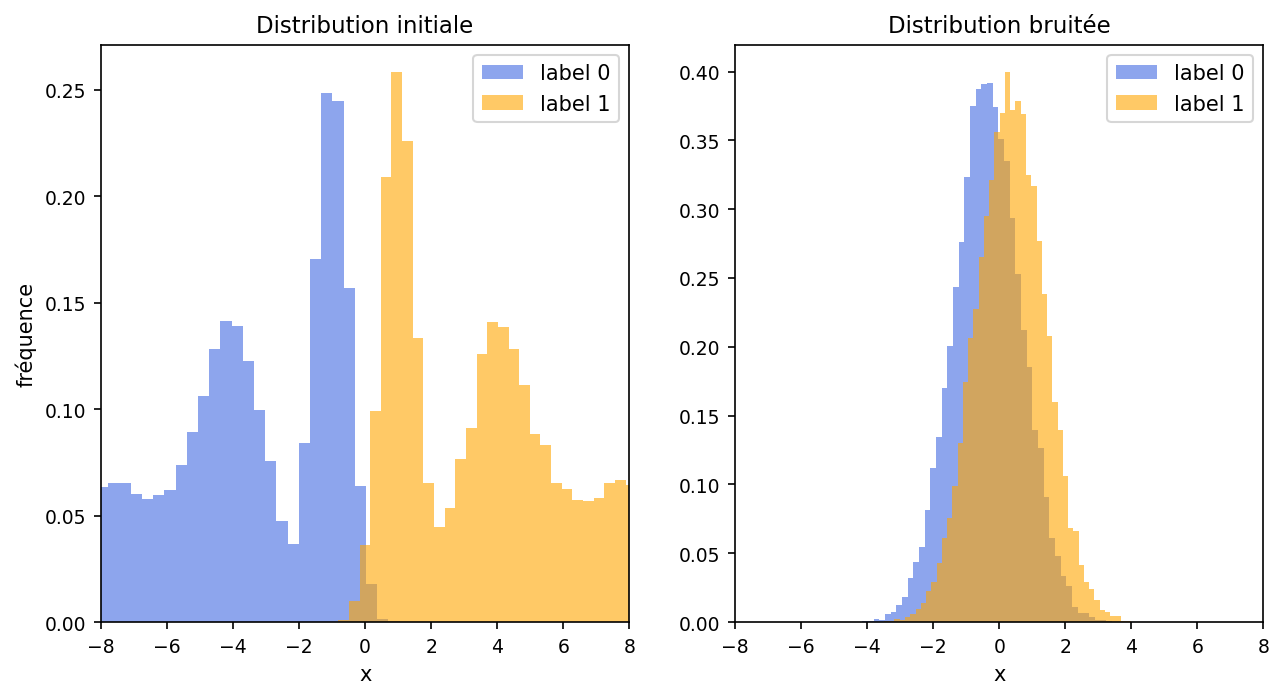

In [59]:
samples_tensor = torch.stack(samples)

# Labels des échantillons
mask0 = labels == 0
mask1 = labels == 1

fig, ax = plt.subplots(1, 2, figsize=(10, 5), sharex=True)

# t = 0
ax[0].hist(
    samples_tensor[0, mask0, 0],
    bins=50,
    density=True,
    alpha=0.6,
    color="royalblue",
    label="label 0"
)

ax[0].hist(
    samples_tensor[0, mask1, 0],
    bins=50,
    density=True,
    alpha=0.6,
    color="orange",
    label="label 1"
)

ax[0].set_xlabel("x")
ax[0].set_ylabel("fréquence")
ax[0].set_xlim(-8, 8)
ax[0].set_title("Distribution initiale")
ax[0].legend()

# t = 250
ax[1].hist(
    samples_tensor[250, mask0, 0],
    bins=50,
    density=True,
    alpha=0.6,
    color="royalblue",
    label="label 0"
)

ax[1].hist(
    samples_tensor[250, mask1, 0],
    bins=50,
    density=True,
    alpha=0.6,
    color="orange",
    label="label 1"
)

ax[1].set_xlabel("x")
ax[1].set_xlim(-8, 8)
ax[1].set_title("Distribution bruitée")
ax[1].legend()

plt.show()

# Entrainement 
On se place dans un cas tres simple, ou le modele de diffusion en degradant d'abord les données d'exemple, puis essaye de les reconstruire depuis un exemple moins bruité, a chaque étape du processus de degradation. 
La loss utilisé ici sera un maximum de vraissemblance ("upper bound on the negative log likelihood" en anglais),
$$ L := \mathbb{E}_q \left[ - \log p(x_T) - \sum_{t=1}^{T} \log \frac{p_\theta(x_{t-1} \mid x_t)}{q(x_t \mid x_{t-1})} \right] $$
Ou la sortie du modele generatif ( probleme inverse ) a la forme de, 
$$ q(x_t | x_{t-1}) := \mathcal{N}(x_{t-1};\mu_{\theta}(x,t),\Sigma_{\theta}(x_t,t)) $$

Il est important de voir qu'ici on entraine 2 réseaux de neuronnes, $\mu_\theta$ et $\Sigma_\theta$ prennant comme entré un échantillon bruité $x_t$ a une itération t, et essayant de predire les parametre de la distribution de l'echantillon $x_{t-1}$. 

Intuitivement on entraine ces reseaux a prédire $x_{t-1}$ basé sur $x_t$, a savoir le terme $p_\theta(x_{t-1} \mid x_t)$ dans la loss, pour chaque étape de diffusion.

Les autres élement de la loss sont ici des élement théorique $q(x_{t-1} \mid x_t)$ assurant que la loss puisse devenir parfaitement nulle pour ce cas spécifique de 2 gaussiennes

In [ ]:
import torch.nn.functional as F

eps_model = torch.nn.Sequential(
    torch.nn.Linear(3, 32),
    torch.nn.ReLU(),
    torch.nn.Linear(32, 32),
    torch.nn.ReLU(),
    torch.nn.Linear(32, 1)
)

optim = torch.optim.AdamW(
    eps_model.parameters(),
    lr=1e-3,
    weight_decay=1e-6,
)

def compute_loss(x0, labels, model):
    batch_size = x0.shape[0]

    t = torch.randint(
        1,
        TIME_STEPS + 1,
        (batch_size, 1),
        device=x0.device,
        dtype=x0.dtype
    )

    alpha_bar = (1 - BETA) ** t.float()
    eps = torch.randn_like(x0)

    xt = torch.sqrt(alpha_bar) * x0 + torch.sqrt(1 - alpha_bar) * eps

    xin = torch.cat(
        [
            xt,
            t.float() / TIME_STEPS,
            labels[:, None].float(),
        ],
        dim=1,
    )

    eps_pred = model(xin)

    return F.mse_loss(eps_pred, eps)

In [72]:
loss_history = []
bar = tqdm(range(10000))

for e in bar:
    optim.zero_grad()

    loss = compute_loss(dataset, labels, eps_model)

    loss.backward()
    optim.step()

    bar.set_description(f"Loss: {loss.item():.4f}")
    loss_history.append(loss.item())

Loss: 0.4593: 100%|██████████| 10000/10000 [04:13<00:00, 39.40it/s]


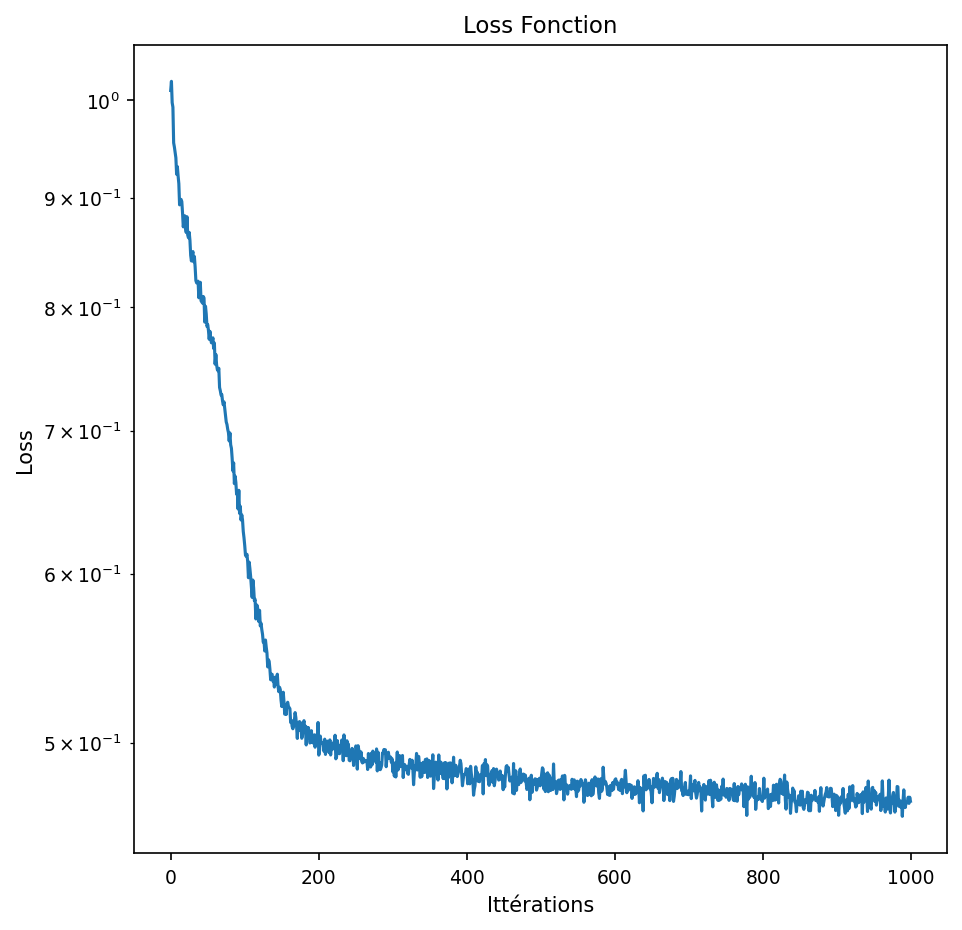

In [68]:
fig, ax = plt.subplots(1, 1, figsize=(7, 7), sharex=True)
ax.plot(loss_history)
ax.set_yscale('log')
ax.set_ylabel('Loss')
ax.set_xlabel('Ittérations')
ax.set_title('Loss Fonction')
plt.show()

# Géneration de données

In [69]:
def sample_reverse(model, labels, steps=TIME_STEPS, beta=BETA):
    count = labels.shape[0]
    device = next(model.parameters()).device

    labels = labels.to(device)
    xt = torch.randn(count, 1, device=device)
    sample_history = [xt.detach().cpu()]

    for t in range(steps, 0, -1):
        t_feature = torch.full(
            (count, 1),
            t / steps,
            device=device,
        )

        xin = torch.cat(
            [
                xt,
                t_feature,
                labels[:, None].float(),
            ],
            dim=1,
        )

        eps_pred = model(xin)

        alpha = 1 - beta
        alpha_bar = alpha ** t

        mean = (1 / np.sqrt(alpha)) * (
            xt - (beta / np.sqrt(1 - alpha_bar)) * eps_pred
        )

        if t > 1:
            noise = torch.randn_like(xt)
            xt = mean + np.sqrt(beta) * noise
        else:
            xt = mean

        sample_history.append(xt.detach().cpu())

    return torch.stack(sample_history)


In [70]:
labels0 = torch.zeros(5000, dtype=torch.long)
labels1 = torch.ones(5000, dtype=torch.long)

samples0 = sample_reverse(eps_model, labels0)
samples1 = sample_reverse(eps_model, labels1)

generated0 = samples0[-1]
generated1 = samples1[-1]


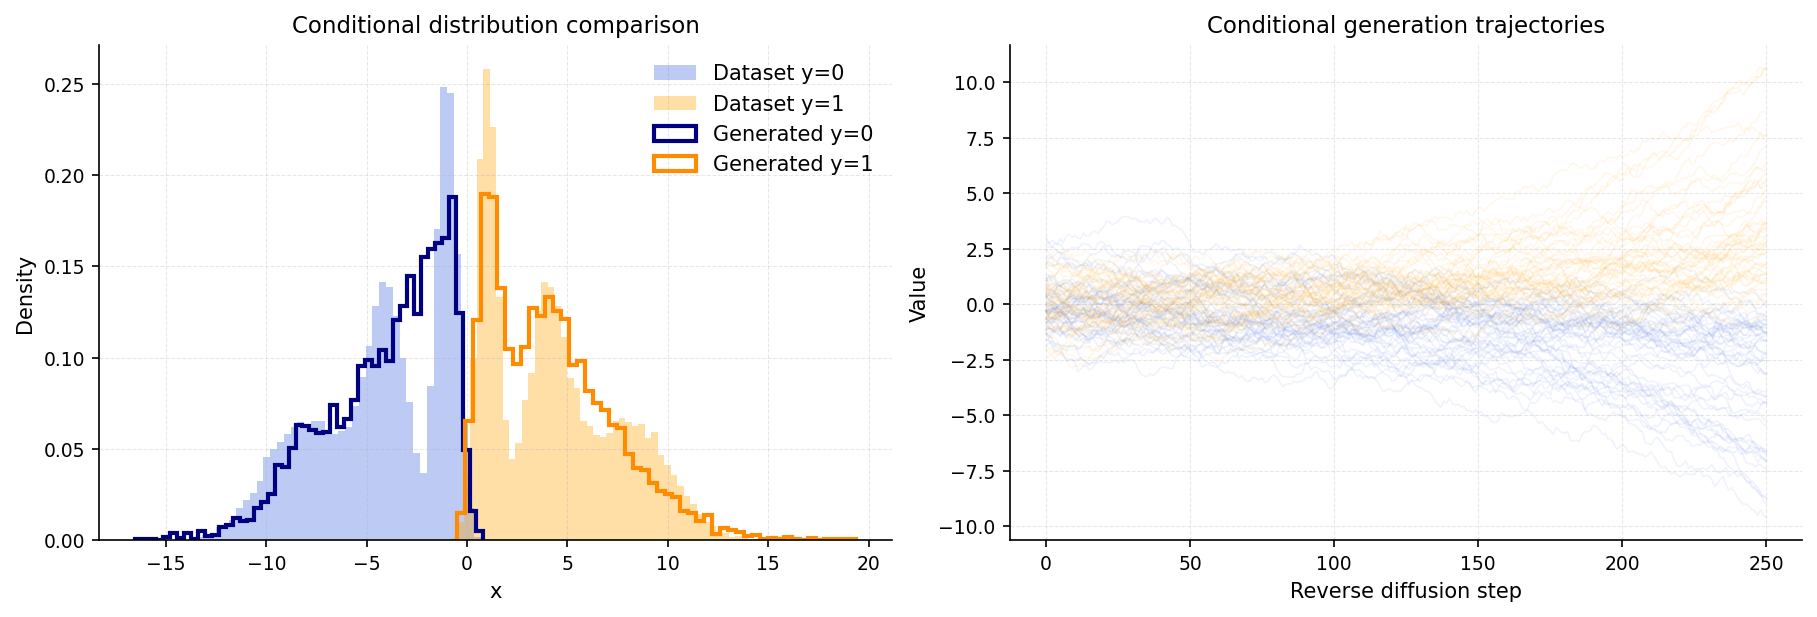

In [71]:
plt.rcParams.update({
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "figure.dpi": 150,
})

fig, ax = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

# LEFT: conditional histograms
ax[0].hist(
    dataset[labels == 0, 0],
    bins=50,
    density=True,
    color="royalblue",
    alpha=0.35,
    label="Dataset y=0",
)
ax[0].hist(
    dataset[labels == 1, 0],
    bins=50,
    density=True,
    color="orange",
    alpha=0.35,
    label="Dataset y=1",
)
ax[0].hist(
    generated0[:, 0],
    bins=50,
    density=True,
    histtype="step",
    linewidth=2,
    color="navy",
    label="Generated y=0",
)
ax[0].hist(
    generated1[:, 0],
    bins=50,
    density=True,
    histtype="step",
    linewidth=2,
    color="darkorange",
    label="Generated y=1",
)

ax[0].set_title("Conditional distribution comparison")
ax[0].set_xlabel("x")
ax[0].set_ylabel("Density")
ax[0].legend(frameon=False)

# RIGHT: reverse trajectories
for trajectory in samples0[:, :50, 0].T:
    ax[1].plot(
        trajectory,
        color="royalblue",
        alpha=0.08,
        linewidth=0.8,
    )

for trajectory in samples1[:, :50, 0].T:
    ax[1].plot(
        trajectory,
        color="orange",
        alpha=0.08,
        linewidth=0.8,
    )

ax[1].set_title("Conditional generation trajectories")
ax[1].set_xlabel("Reverse diffusion step")
ax[1].set_ylabel("Value")

for a in ax:
    a.grid(True, linestyle="--", linewidth=0.5, alpha=0.3)
    a.spines["top"].set_visible(False)
    a.spines["right"].set_visible(False)

plt.show()
